In [1]:
#!pip install shap
#!pip install xgboost
#!pip install catboost


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score,f1_score,confusion_matrix,ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

import shap

In [3]:
#Load Dataset
df = pd.read_csv("studentdropout.csv")
df.sample(10)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
3842,1,12,1,4,1,12,1,3,1,3,...,0,6,10,0,0.000000,0,13.9,-0.3,0.79,Dropout
1900,1,14,1,15,1,1,1,1,27,4,...,0,6,8,6,12.666667,0,12.4,0.5,1.79,Graduate
210,1,1,2,12,1,1,1,23,1,8,...,0,8,8,7,12.642857,0,12.7,3.7,-1.70,Graduate
2189,1,8,4,15,1,1,1,1,1,6,...,0,6,6,6,12.333333,0,12.7,3.7,-1.70,Dropout
612,1,1,1,5,1,1,1,1,1,2,...,0,6,10,6,11.166667,0,12.4,0.5,1.79,Graduate
2986,1,14,2,16,1,1,1,13,1,6,...,0,6,8,4,11.500000,0,10.8,1.4,1.74,Enrolled
1013,1,1,2,15,1,1,1,13,1,5,...,0,6,0,0,0.000000,0,11.1,0.6,2.02,Dropout
914,1,12,1,12,1,1,1,22,27,10,...,0,8,0,0,0.000000,0,13.9,-0.3,0.79,Dropout
153,1,1,1,16,1,1,1,22,27,10,...,0,6,8,5,11.800000,0,7.6,2.6,0.32,Graduate
3246,1,8,1,15,1,1,1,2,3,3,...,0,6,6,6,13.500000,0,11.1,0.6,2.02,Graduate


In [4]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

(4424, 35)

In [5]:
summary = pd.DataFrame({
    "Feature Name": df.columns,
    "Type": df.dtypes.values,
    "Min": df.min(numeric_only=True).reindex(df.columns),
    "Max": df.max(numeric_only=True).reindex(df.columns),
    "Unique Values": df.nunique().values
})

# Reset index properly
summary.reset_index(drop=True, inplace=True)

summary

,Feature Name,Type,Min,Max,Unique Values
0,Marital status,int64,1.00,6.000000,6
1,Application mode,int64,1.00,18.000000,18
2,Application order,int64,0.00,9.000000,8
3,Course,int64,1.00,17.000000,17
4,Daytime/evening attendance,int64,0.00,1.000000,2
5,Previous qualification,int64,1.00,17.000000,17
6,Nacionality,int64,1.00,21.000000,21
7,Mother's qualification,int64,1.00,29.000000,29
8,Father's qualification,int64,1.00,34.000000,34
9,Mother's occupation,int64,1.00,32.000000,32


In [6]:
def classify_feature(col):
    if df[col].dtype == 'object':
        return "Categorical"
    elif df[col].nunique() < 10:
        return "Ordinal"
    else:
        return "Numerical"

summary["Type"] = [classify_feature(col) for col in df.columns]

def get_range(col):
    if df[col].dtype != 'object':
        return f"{df[col].min()} to {df[col].max()}"
    else:
        return ", ".join(map(str, df[col].unique()[:5]))  # sample

summary["Feature Range"] = [get_range(col) for col in df.columns]

In [7]:
#Separate Features & Target
X = df.drop("Target", axis=1)
y = df["Target"]


In [12]:
def classify_feature(col):
    if df[col].dtype == 'object':
        return "Categorical"
    elif df[col].nunique() < 10:
        return "Ordinal"
    else:
        return "Numerical"

summary["Type"] = [classify_feature(col) for col in df.columns]

def get_range(col):
    if df[col].dtype != 'object':
        return f"{df[col].min()} to {df[col].max()}"
    else:
        return ", ".join(map(str, df[col].unique()[:5]))  # sample

summary["Feature Range"] = [get_range(col) for col in df.columns]

In [13]:
#Encode Categorical Features
cat_cols = X.select_dtypes(include='object').columns

#le = LabelEncoder()
for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col])

#Encode Target Variable
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print(target_encoder.classes_)

['Dropout' 'Enrolled' 'Graduate']


In [14]:
#Train-Test Split
from imblearn.over_sampling import SMOTE, ADASYN
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Original training class distribution: {np.bincount(y_train)}")

sampler = ADASYN(random_state=42) 

X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

print(f"Resampled training class distribution: {np.bincount(y_train_resampled)}")

Original training class distribution: [1137  635 1767]
Resampled training class distribution: [1742 1631 1767]


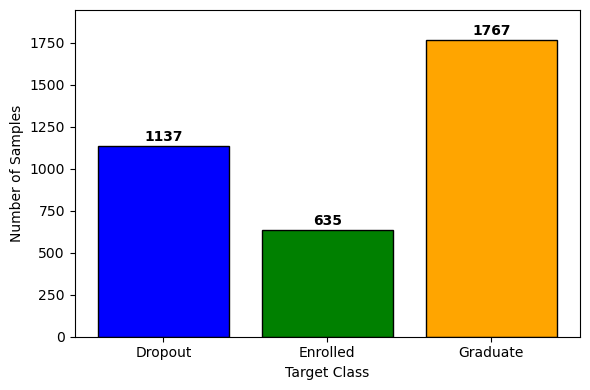

In [16]:
# Get the exact counts for the original training data (Before ADASYN)original_counts = np.bincount(y_train)
original_counts = np.bincount(y_train)
class_labels = target_encoder.classes_

plt.figure(figsize=(6, 4))
bars = plt.bar(class_labels, original_counts, color=['blue', 'green', 'orange'], edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), 
             ha='center', va='bottom', fontsize=10, fontweight='bold')


plt.xlabel('Target Class', fontsize=10)
plt.ylabel('Number of Samples', fontsize=10)

plt.ylim(0, max(original_counts) * 1.1)

plt.tight_layout()
plt.savefig('Original Class Distribution (Before ADASYN)1', dpi=300, bbox_inches='tight')
plt.show()

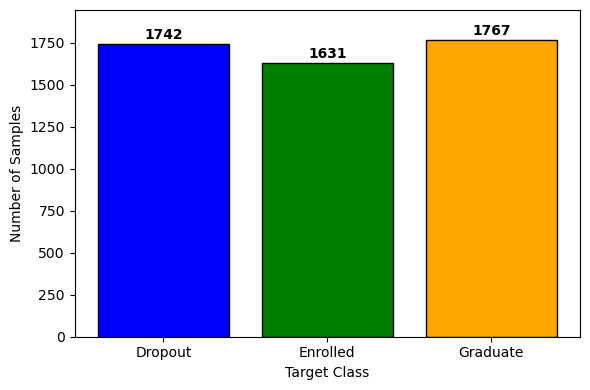

In [17]:
# Get the exact counts for the resampled data
resampled_counts = np.bincount(y_train_resampled)

class_labels = target_encoder.classes_

plt.figure(figsize=(6, 4))
bars = plt.bar(class_labels, resampled_counts, color=['blue', 'green', 'orange'], edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Target Class', fontsize=10)
plt.ylabel('Number of Samples', fontsize=10)

plt.ylim(0, max(original_counts) * 1.1)

plt.tight_layout()
plt.savefig('Resample Class Distribution (After ADASYN)1', dpi=300, bbox_inches='tight')
plt.show()

Accuracy: 0.7616
confuion matrix:  [[209  40  35]
 [ 37  80  42]
 [ 14  43 385]]
              precision    recall  f1-score   support

     Dropout       0.80      0.74      0.77       284
    Enrolled       0.49      0.50      0.50       159
    Graduate       0.83      0.87      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.70      0.71       885
weighted avg       0.76      0.76      0.76       885



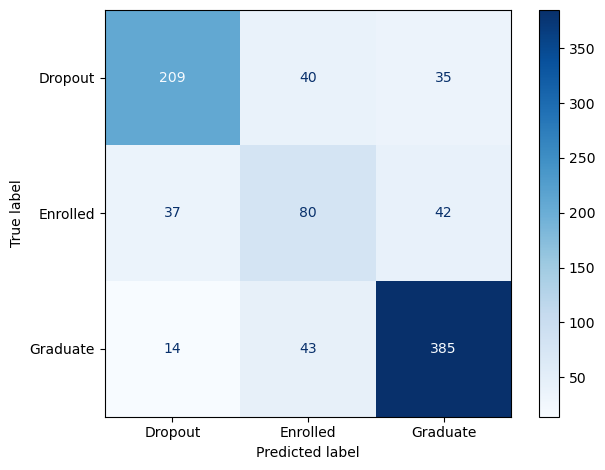

In [18]:
#Train XGBoost Model
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
#xgb_model.fit(X_train, y_train)
xgb_model.fit(X_train_resampled, y_train_resampled)


y_pred = xgb_model.predict(X_test)
cm_xgb = confusion_matrix(y_test, y_pred)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"confuion matrix: ",cm_xgb)
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=target_encoder.classes_)

disp.plot(cmap='Blues', values_format='d')
plt.tight_layout()
plt.savefig('confusion-matrix-XGB', dpi=300, bbox_inches='tight')
plt.show()

Accuracy: 0.7582
confuion matrix:  [[210  39  35]
 [ 38  78  43]
 [ 15  44 383]]
              precision    recall  f1-score   support

     Dropout       0.80      0.74      0.77       284
    Enrolled       0.48      0.49      0.49       159
    Graduate       0.83      0.87      0.85       442

    accuracy                           0.76       885
   macro avg       0.70      0.70      0.70       885
weighted avg       0.76      0.76      0.76       885



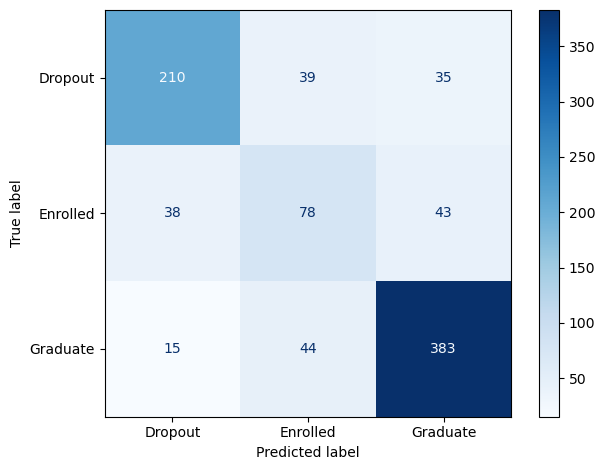

In [19]:
cat_model = CatBoostClassifier(
     verbose=0, 
     random_state=42,
     iterations=500, 
     learning_rate=0.1,  
     depth=6
)

cat_model.fit(X_train_resampled, y_train_resampled)

# 6. Evaluation
y_pred = cat_model.predict(X_test)
cm_cat = confusion_matrix(y_test, y_pred)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"confuion matrix: ",cm_cat)
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_cat, display_labels=target_encoder.classes_)

disp.plot(cmap='Blues', values_format='d')
plt.tight_layout()
plt.savefig('confusion-matrix-CAT', dpi=300, bbox_inches='tight')
plt.show()

Accuracy: 0.7401
confuion matrix:  [[196  62  26]
 [ 27 101  31]
 [ 16  68 358]]
              precision    recall  f1-score   support

     Dropout       0.82      0.69      0.75       284
    Enrolled       0.44      0.64      0.52       159
    Graduate       0.86      0.81      0.84       442

    accuracy                           0.74       885
   macro avg       0.71      0.71      0.70       885
weighted avg       0.77      0.74      0.75       885



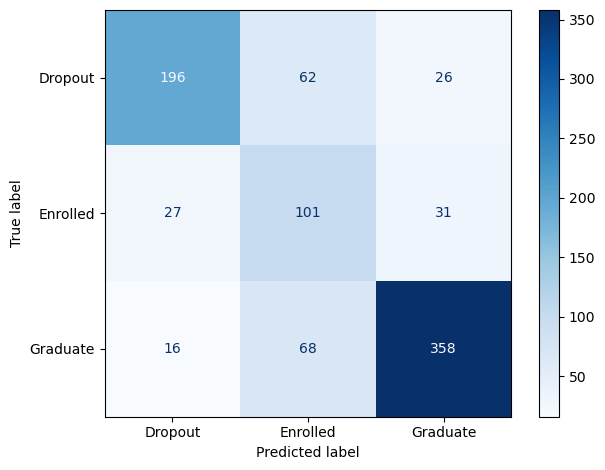

In [20]:
rnf_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        class_weight="balanced",
        random_state=42
    )
rnf_model.fit(X_train_resampled, y_train_resampled)

# Evaluation
y_pred = rnf_model.predict(X_test)
cm_rnf = confusion_matrix(y_test, y_pred)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"confuion matrix: ",cm_rnf)
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rnf, display_labels=target_encoder.classes_)

disp.plot(cmap='Blues', values_format='d')
plt.tight_layout()
plt.savefig('confusion-matrix-RNF1', dpi=300, bbox_inches='tight')
plt.show()


In [21]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from scipy.stats import ttest_rel, wilcoxon

In [22]:
# 1. Setup the 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define models
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
cat = CatBoostClassifier(random_state=42, verbose=0)

# 2. Calculate the 5-fold scores for each model using the original full dataset (X, y_encoded)
print("Running 5-Fold CV... please wait...")
rf_scores = cross_val_score(rf, X, y_encoded, cv=cv, scoring='accuracy')
xgb_scores = cross_val_score(xgb, X, y_encoded, cv=cv, scoring='accuracy')
cat_scores = cross_val_score(cat, X, y_encoded, cv=cv, scoring='accuracy')

# 3. Print the Result Table
print("\n--- 5-Fold Cross Validation Results ---")
print(f"{'Model':<15} | {'Mean Accuracy':<15} | {'Std Dev':<15}")
print("-" * 50)
print(f"{'Random Forest':<15} | {np.mean(rf_scores):.4f}          | {np.std(rf_scores):.4f}")
print(f"{'CatBoost':<15} | {np.mean(cat_scores):.4f}          | {np.std(cat_scores):.4f}")
print(f"{'XGBoost':<15} | {np.mean(xgb_scores):.4f}          | {np.std(xgb_scores):.4f}")

# 4. Statistical Significance Testing
t_stat_rf, p_val_rf = ttest_rel(xgb_scores, rf_scores)
t_stat_cat, p_val_cat = ttest_rel(xgb_scores, cat_scores)

print("\n--- Statistical Significance Testing ---")
print(f"XGBoost vs Random Forest: p-value = {p_val_rf:.4f}")
if p_val_rf < 0.05:
    print("-> The improvement of XGBoost over RF IS statistically significant.")
else:
    print("-> The improvement is NOT statistically significant.")

print(f"XGBoost vs CatBoost: p-value = {p_val_cat:.4f}")
if p_val_cat < 0.05:
    print("-> The improvement of XGBoost over CatBoost IS statistically significant.")
else:
    print("-> The improvement is NOT statistically significant.")

Running 5-Fold CV... please wait...

--- 5-Fold Cross Validation Results ---
Model           | Mean Accuracy   | Std Dev        
--------------------------------------------------
Random Forest   | 0.7717          | 0.0075
CatBoost        | 0.7767          | 0.0067
XGBoost         | 0.7708          | 0.0061

--- Statistical Significance Testing ---
XGBoost vs Random Forest: p-value = 0.8765
-> The improvement is NOT statistically significant.
XGBoost vs CatBoost: p-value = 0.0567
-> The improvement is NOT statistically significant.


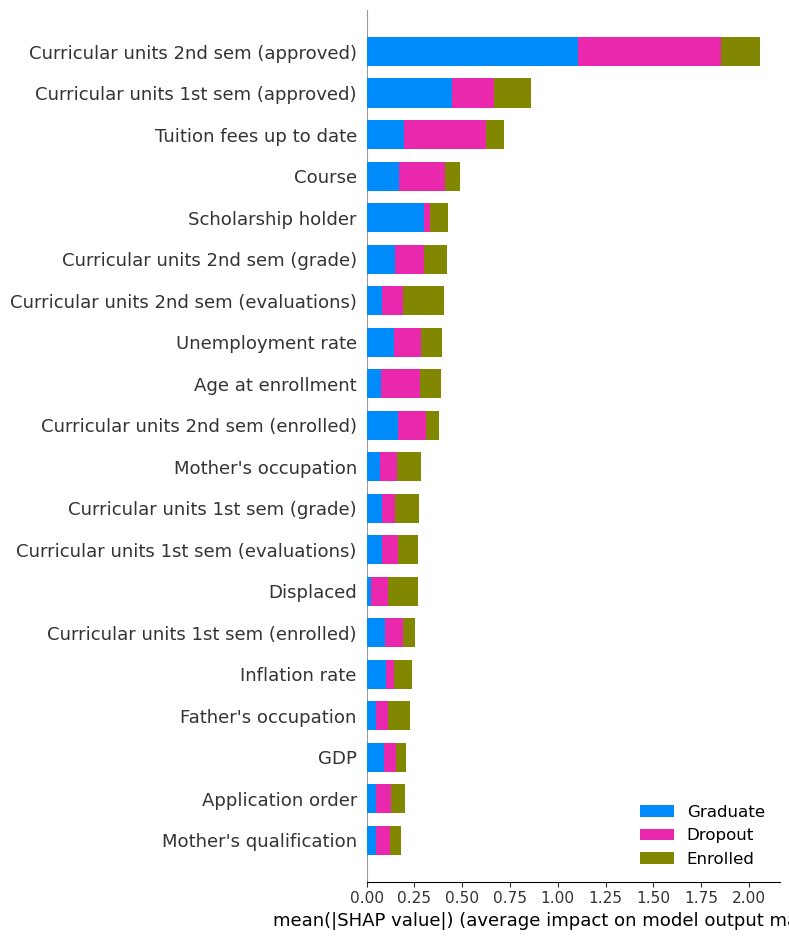

In [23]:
#SHAP for explain
shap.initjs()

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

#shap.summary_plot(shap_values, X_test)
plt.figure(figsize=(15, 8))
shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type="bar", 
    class_names=target_encoder.classes_,
    title="Global Feature Importance (SHAP)",
    show = False
)
plt.tight_layout()
plt.savefig('summary_plot1.png', dpi=300, bbox_inches='tight')
plt.show()

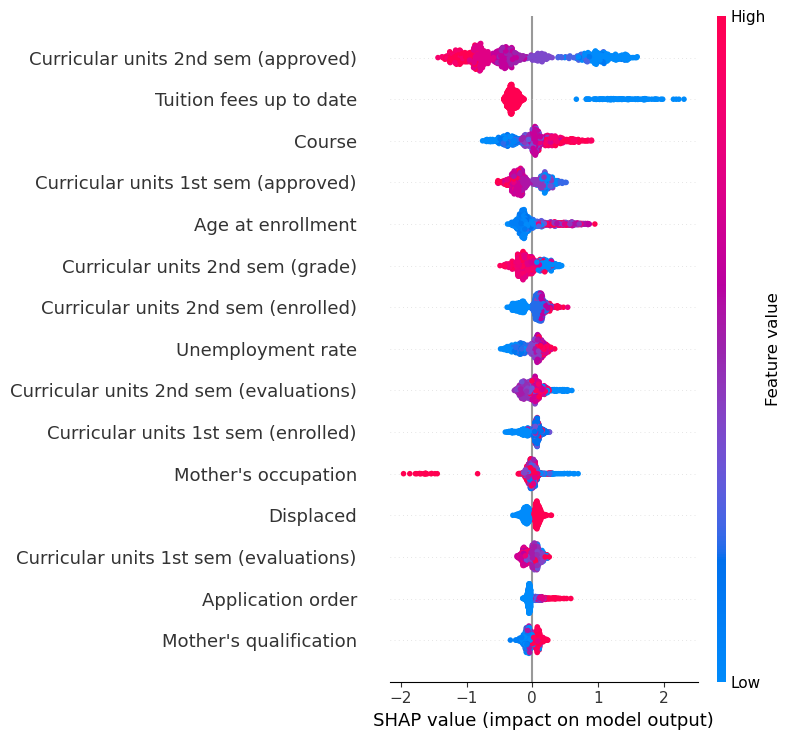

In [24]:
# Initialize the Explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    # If it returns a list: [Class0_Matrix, Class1_Matrix, Class2_Matrix]
    shap_data = shap_values[0]
elif len(shap_values.shape) == 3:
    # If it returns a 3D Array: (Samples, Features, Classes)
    shap_data = shap_values[:, :, 0]
else:
    # Fallback for binary/other shapes
    shap_data = shap_values

# Generate the Beeswarm Plot
plt.figure(figsize=(12, 10))
#plt.title(f"Top Features Driving '{target_encoder.classes_[0]}'", fontsize=16)

shap.summary_plot(
    shap_data, 
    X_test, 
    max_display=15, 
    show=False
)

plt.tight_layout()
plt.savefig('summary_plot_Beeswarm1', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
#Check with random value for all columns

columns = ['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       "Mother's qualification", "Father's qualification",
       "Mother's occupation", "Father's occupation", 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)', 'Unemployment rate',
       'Inflation rate', 'GDP']

# Input values
new_student_data = {
       'Marital status': 1,'Application mode':12, 
       'Application order':1,'Course':11,
       'Daytime/evening attendance':0, 'Previous qualification':1, 'Nacionality':1,
       "Mother's qualification":22, "Father's qualification":28,
       "Mother's occupation":6, "Father's occupation":11, 'Displaced':0,
       'Educational special needs':0, 'Debtor':0, 'Tuition fees up to date':0,
       'Gender':1, 'Scholarship holder':0, 'Age at enrollment':25, 'International':0,
       'Curricular units 1st sem (credited)':0,
       'Curricular units 1st sem (enrolled)':6,
       'Curricular units 1st sem (evaluations)':5,
       'Curricular units 1st sem (approved)':3,
       'Curricular units 1st sem (grade)':0,
       'Curricular units 1st sem (without evaluations)':0,
       'Curricular units 2nd sem (credited)':0,
       'Curricular units 2nd sem (enrolled)':5,
       'Curricular units 2nd sem (evaluations)':17,
       'Curricular units 2nd sem (approved)':0,
       'Curricular units 2nd sem (grade)':0,
       'Curricular units 2nd sem (without evaluations)':0, 'Unemployment rate':10.8,
       'Inflation rate':2.8, 'GDP':1.75
}

# Convert to DataFrame
new_student_df = pd.DataFrame([new_student_data])

prediction = xgb_model.predict(new_student_df)

# Output result
if prediction[0] == 0:
    print("Prediction: Dropout")
elif prediction[0] == 1:
    print("Prediction: Enrolled")
else:
    print("Prediction: Graduate")

Prediction: Dropout


In [26]:
prediction_index = int(xgb_model.predict(new_student_df)[0])
predicted_class = target_encoder.classes_[prediction_index]

print(f"--- PREDICTION REPORT ---")
print(f"The model predicts this student will: {predicted_class.upper()}")
print("-" * 30)

shap_values_single = explainer(new_student_df)

if isinstance(shap_values_single.values, list):
    # If it's a list, pick the matrix for the predicted class
    student_values = shap_values_single.values[prediction_index][0]
elif len(shap_values_single.values.shape) == 3:
    # If it's a 3D array, slice it: [Row 0, All Features, Predicted Class Index]
    student_values = shap_values_single.values[0, :, prediction_index]
else:
    # Binary classification case
    student_values = shap_values_single.values[0]

feature_names = new_student_df.columns
contributions = []

for i, feature in enumerate(feature_names):
    contributions.append({
        "feature": feature,
        "shap_value": student_values[i],  
        "actual_value": new_student_df.iloc[0, i] 
    })

# 5. Sort by "Importance" (Absolute SHAP value) - Biggest impact first
contributions.sort(key=lambda x: abs(x["shap_value"]), reverse=True)

# 6. Print the explanation in Simple English
print(f"Top 3 reasons for predicting '{predicted_class}':\n")

for item in contributions[:3]: # Look at top 3 only
    feature = item['feature']
    val = item['actual_value']
    impact = item['shap_value']
    
    # Determine if it pushed towards or away from the prediction
    direction = "INCREASED" if impact > 0 else "DECREASED"
    
    print(f"• Because '{feature}' is {val}:")
    print(f"  -> It {direction} the chance of being '{predicted_class}'.")
    print("")

--- PREDICTION REPORT ---
The model predicts this student will: DROPOUT
------------------------------
Top 3 reasons for predicting 'Dropout':

• Because 'Tuition fees up to date' is 0:
  -> It INCREASED the chance of being 'Dropout'.

• Because 'Curricular units 2nd sem (approved)' is 0:
  -> It INCREASED the chance of being 'Dropout'.

• Because 'Course' is 11:
  -> It INCREASED the chance of being 'Dropout'.



<Figure size 1000x600 with 0 Axes>

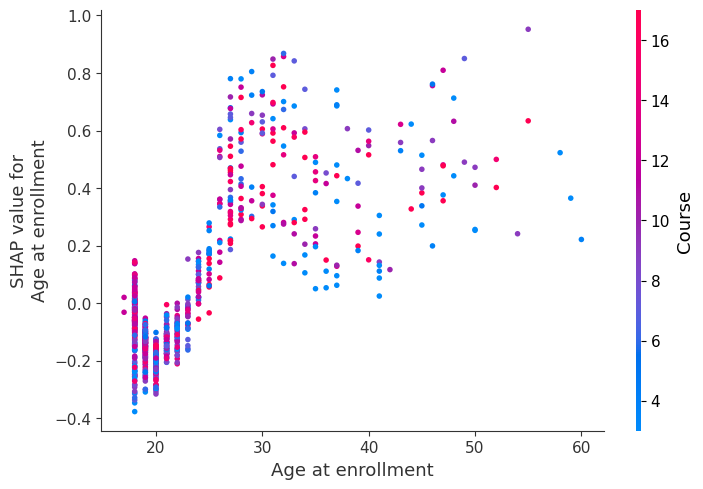

In [27]:
# Joint Effect: Age & Course on Dropout Risk
plt.figure(figsize=(10, 6))

shap.dependence_plot(
    "Age at enrollment",
    shap_data,         
    X_test,                
    interaction_index="Course",
    show=False             
)

#plt.title("Joint Effect: Age & Course on Dropout Risk")
plt.tight_layout()
#plt.savefig('Joint Effect of Age&Course on Dropout Risk1', dpi=300, bbox_inches='tight')
plt.show()

1st Sem Threshold: Passing 5 or more subjects reduces dropout risk.
2nd Sem Threshold: Passing 4 or more subjects reduces dropout risk.


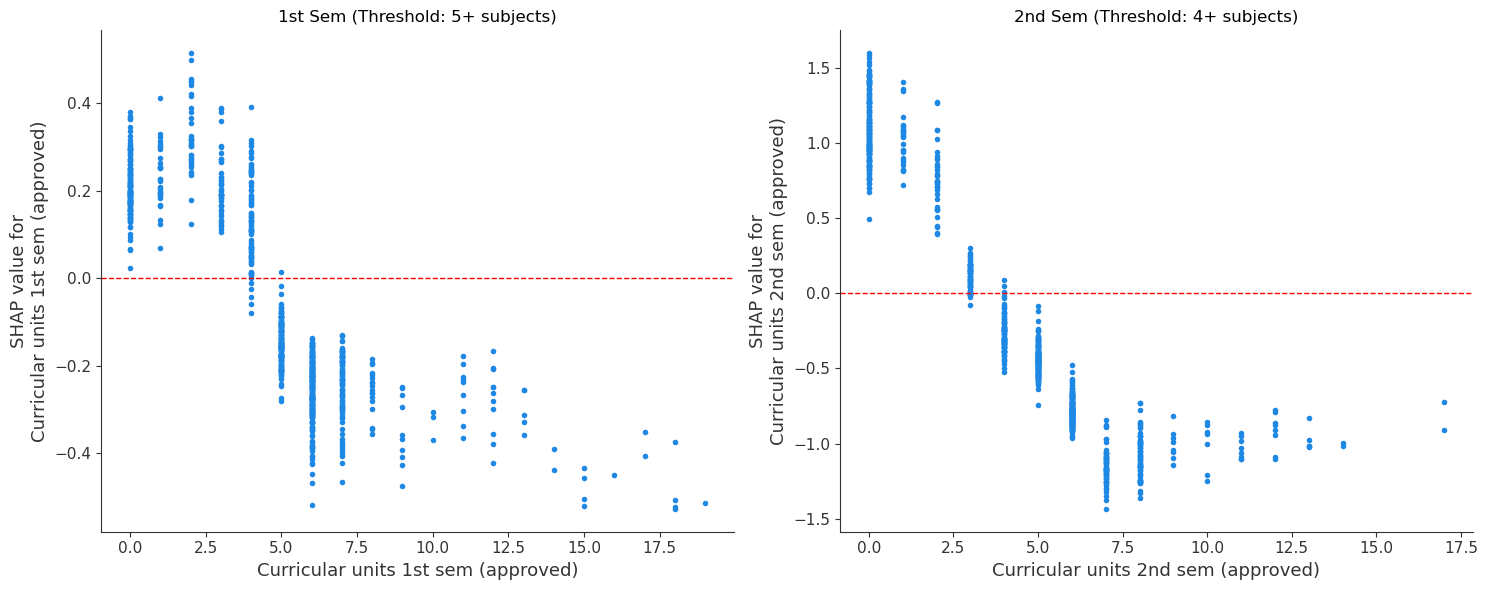

In [28]:
#Curricular units 1st & 2nd sem approved impact
def get_shap_threshold(feature_name, shap_values_class0, X_test):
    # Create a DataFrame of Feature Values vs SHAP Values
    df_shap = pd.DataFrame({
        'feature_value': X_test[feature_name],
        'shap_value': shap_values_class0[:, X_test.columns.get_loc(feature_name)]
    })
    
    # Calculate the average SHAP value for each number of approved units
    mean_shap = df_shap.groupby('feature_value')['shap_value'].mean()
    
    # Find the first value where the average SHAP becomes NEGATIVE (Low Risk)
    threshold = mean_shap[mean_shap < 0].index.min()
    
    return threshold, mean_shap

if isinstance(shap_values, list):
    shap_class0 = shap_values[0] 
else:
    shap_class0 = shap_values[:, :, 0]

# Analyze 1st Semester
thresh1, means1 = get_shap_threshold("Curricular units 1st sem (approved)", shap_class0, X_test)
print(f"1st Sem Threshold: Passing {thresh1} or more subjects reduces dropout risk.")

# Analyze 2nd Semester
thresh2, means2 = get_shap_threshold("Curricular units 2nd sem (approved)", shap_class0, X_test)
print(f"2nd Sem Threshold: Passing {thresh2} or more subjects reduces dropout risk.")

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

shap.dependence_plot("Curricular units 1st sem (approved)", shap_class0, X_test, ax=ax[0], show=False, interaction_index=None)
ax[0].axhline(0, color='red', linestyle='--', linewidth=1)
ax[0].set_title(f"1st Sem (Threshold: {thresh1}+ subjects)")

shap.dependence_plot("Curricular units 2nd sem (approved)", shap_class0, X_test, ax=ax[1], show=False, interaction_index=None)
ax[1].axhline(0, color='red', linestyle='--', linewidth=1)
ax[1].set_title(f"2nd Sem (Threshold: {thresh2}+ subjects)")

plt.tight_layout()
#plt.savefig('Curricular units 1st&2nd sem approved1', dpi=300, bbox_inches='tight')
plt.show()

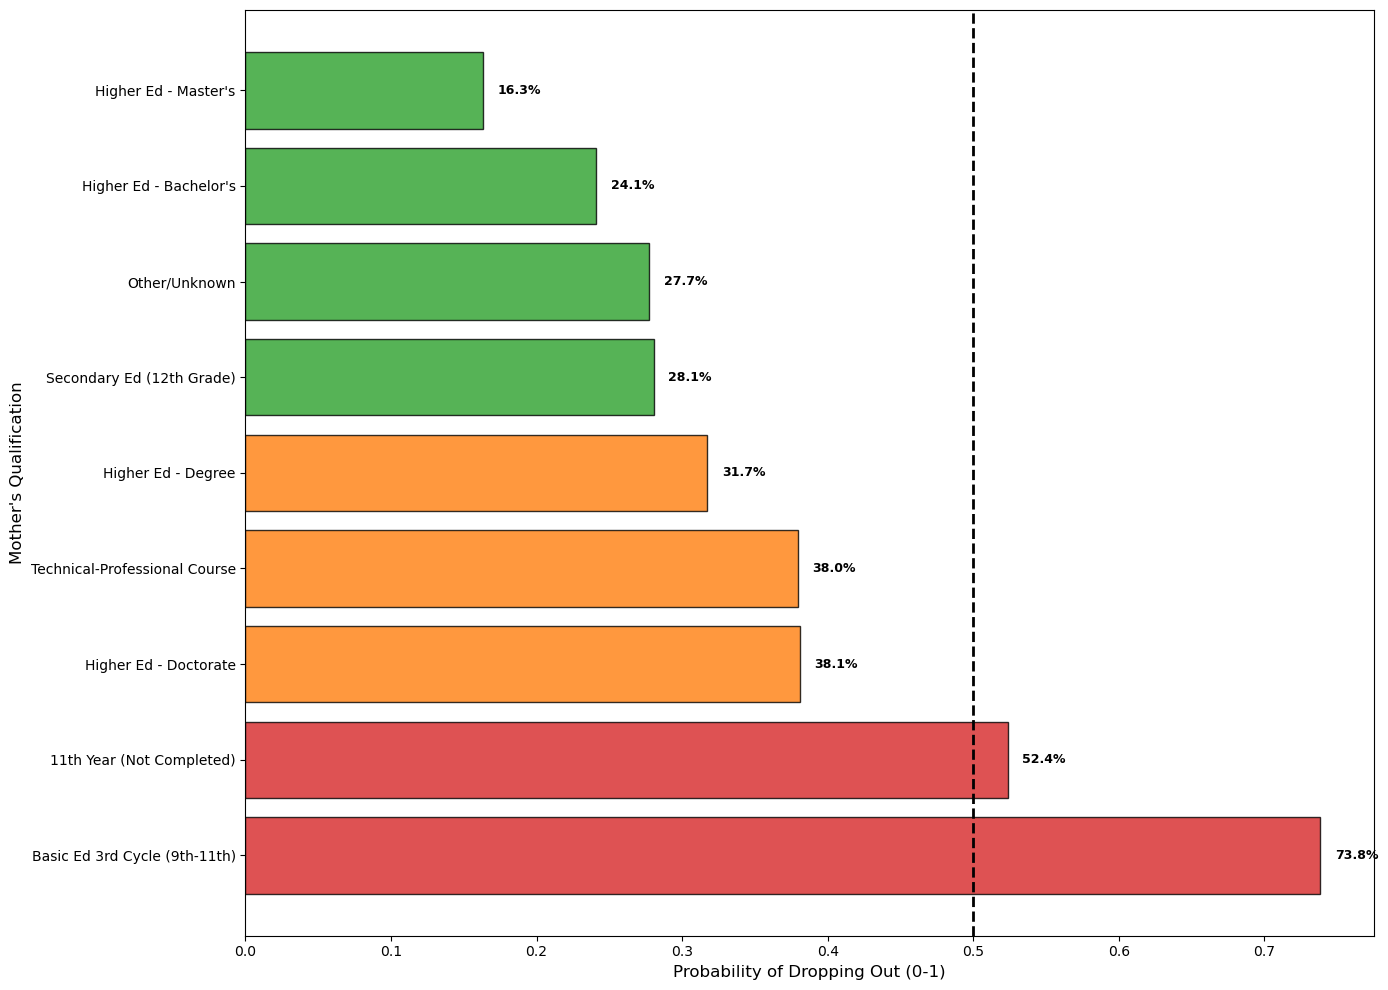

In [29]:
# Minimum Qualification Required to Reduce Dropout Risk\n(Data Source: Paper Appendix Codes
df['Is_Dropout'] = (df['Target'] == 'Dropout').astype(int)

qualification_map = {
    1: "Secondary Ed (12th Grade)",
    2: "Higher Ed - Bachelor's",
    3: "Higher Ed - Degree",
    4: "Higher Ed - Master's",
    5: "Higher Ed - Doctorate",
    6: "Freq. of Higher Ed",
    9: "12th Year (Not Completed)",
    10: "11th Year (Not Completed)",
    11: "7th Year (Old)",
    12: "Other - 11th Year",
    14: "10th Year",
    18: "General Commerce Course",
    19: "Basic Ed 3rd Cycle (9th-11th)",
    22: "Technical-Professional Course",
    26: "7th Year (Schooling)",
    27: "2nd Cycle General High School",
    29: "9th Year (Not Completed)",
    30: "8th Year (Schooling)",
    34: "Unknown",
    35: "Can't Read/Write",
    36: "Can Read/Write",
    37: "Basic Ed 1st Cycle (4th)",
    38: "Basic Ed 2nd Cycle (6th-8th)",
    40: "Higher Ed - Degree (1st cycle)",
    41: "Higher Ed - Professional Higher Tech",
    42: "Higher Ed - Master",
    43: "Higher Ed - Doctorate",
}

df['Mother_Qual_Label'] = df["Mother's qualification"].map(qualification_map)
df['Mother_Qual_Label'] = df['Mother_Qual_Label'].fillna("Other/Unknown")

# Calculate Dropout Rate per Qualification
stats = df.groupby('Mother_Qual_Label')['Is_Dropout'].agg(['mean', 'count'])

stats_robust = stats[stats['count'] >= 20].sort_values('mean', ascending=False)

plt.figure(figsize=(14, 10))

# Red (>50% risk), Green (<30% risk), Orange (In-between)
colors = ['#d62728' if x > 0.5 else '#2ca02c' if x < 0.3 else '#ff7f0e' for x in stats_robust['mean']]

bars = plt.barh(stats_robust.index, stats_robust['mean'], color=colors, edgecolor='black', alpha=0.8)

# Add Threshold Line
plt.axvline(0.5, color='black', linestyle='--', linewidth=2, label='50% Risk Line')

#plt.title("Minimum Qualification Required to Reduce Dropout Risk\n(Data Source: Paper Appendix Codes)", fontsize=14)
plt.xlabel("Probability of Dropping Out (0-1)", fontsize=12)
plt.ylabel("Mother's Qualification", fontsize=12)

# Add data labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{width:.1%}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
# plt.savefig("Dropout_mothersqualification1", dpi=300, bbox_inches='tight')
plt.show()

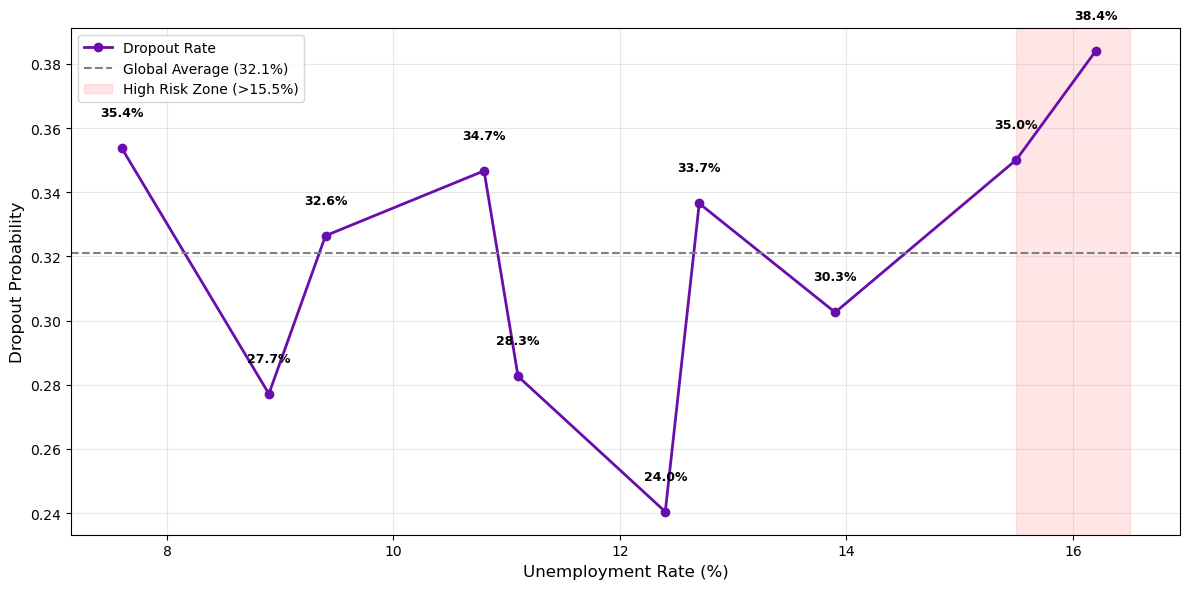


--- Data Summary ---
                       mean  count
Unemployment rate                 
7.6                0.353765    571
8.9                0.277174    368
9.4                0.326454    533
10.8               0.346667    525
11.1               0.282609    414
12.4               0.240449    445
12.7               0.336516    419
13.9               0.302564    390
15.5               0.350126    397
16.2               0.383978    362


In [30]:
# Impact of Unemployment Rate on Dropout Risk
stats = df.groupby('Unemployment rate')['Is_Dropout'].agg(['mean', 'count'])
stats = stats.sort_index()

plt.figure(figsize=(12, 6))

plt.plot(stats.index, stats['mean'], marker='o', linestyle='-', color='#6a0dad', linewidth=2, label='Dropout Rate')

global_rate = df['Is_Dropout'].mean()
plt.axhline(global_rate, color='gray', linestyle='--', label=f'Global Average ({global_rate:.1%})')

plt.axvspan(15.5, 16.5, color='red', alpha=0.1, label='High Risk Zone (>15.5%)')

# Add Labels and Title
#plt.title("Impact of Unemployment Rate on Dropout Risk", fontsize=14)
plt.xlabel("Unemployment Rate (%)", fontsize=12)
plt.ylabel("Dropout Probability", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Add data labels for clarity
for x, y in zip(stats.index, stats['mean']):
    plt.text(x, y + 0.01, f'{y:.1%}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.tight_layout()
#plt.savefig("unemployment rate on dropout risk1", dpi=300, bbox_inches='tight')
plt.show()


# Print the Exact Data Table
print("\n--- Data Summary ---")
print(stats[['mean', 'count']])

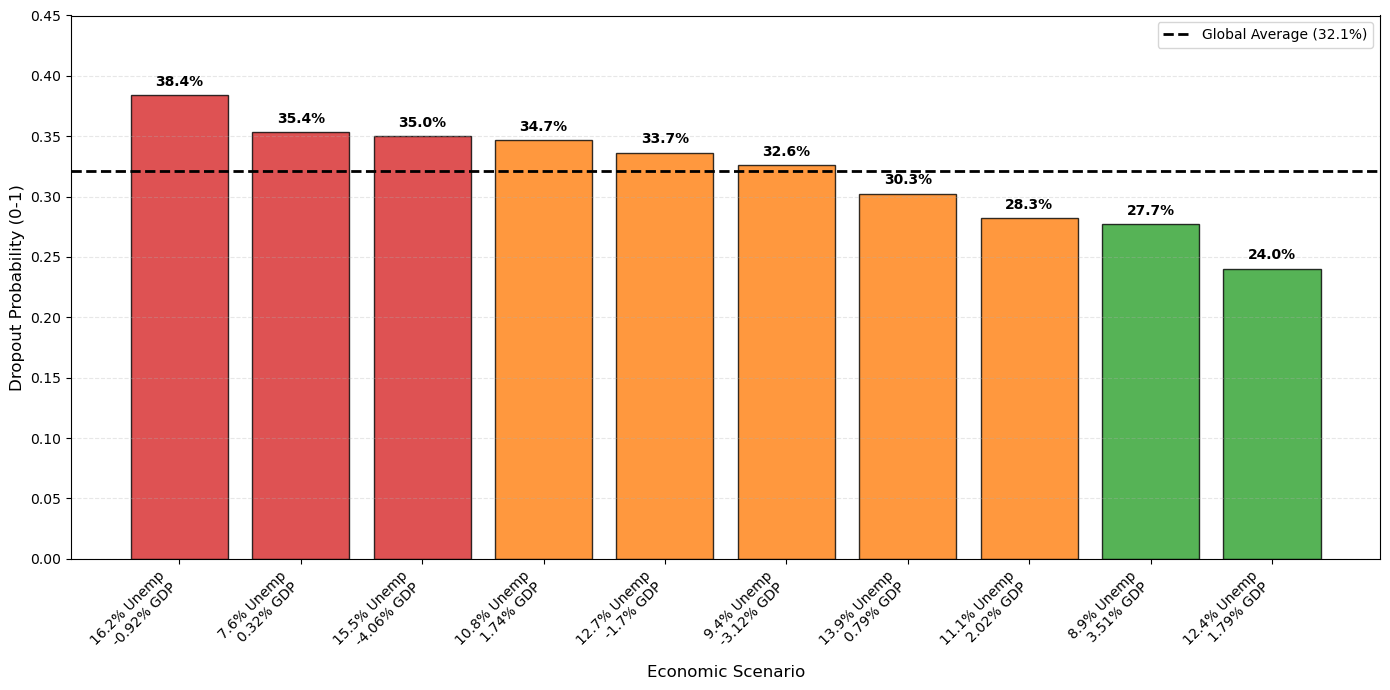

In [31]:
# Combined Effect of Unemployment & GDP on Dropout Risk
scenario_stats = df.groupby(['Unemployment rate', 'GDP'])['Is_Dropout'].agg(['mean', 'count'])
scenario_stats = scenario_stats.reset_index().sort_values('mean', ascending=False)

scenario_stats['Label'] = (
    scenario_stats['Unemployment rate'].astype(str) + "% Unemp\n" + 
    scenario_stats['GDP'].astype(str) + "% GDP"
)

plt.figure(figsize=(14, 7))

# Color Logic: Red (>35% Risk), Green (<28% Risk), Orange (Medium)
colors = []
for rate in scenario_stats['mean']:
    if rate > 0.35:
        colors.append('#d62728')  # Red
    elif rate < 0.28:
        colors.append('#2ca02c')  # Green
    else:
        colors.append('#ff7f0e')  # Orange

bars = plt.bar(scenario_stats['Label'], scenario_stats['mean'], color=colors, edgecolor='black', alpha=0.8)

# Add Global Average Line
global_avg = df['Is_Dropout'].mean()
plt.axhline(global_avg, color='black', linestyle='--', linewidth=2, label=f'Global Average ({global_avg:.1%})')

#plt.title("Combined Effect of Unemployment & GDP on Dropout Risk\n(Sorted from Highest Risk to Lowest)", fontsize=14)
plt.ylabel("Dropout Probability (0-1)", fontsize=12)
plt.xlabel("Economic Scenario", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 0.45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, 
             f'{height:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
#plt.savefig("combined effect of unemployment & GDP on dropout risk1", dpi=300, bbox_inches='tight')
plt.show()

In [37]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import joblib
import os

# Ensure the export directory exists on your external drive
os.makedirs("exported_assets", exist_ok=True)

# 1. Define the individual models (Strictly forcing CPU execution)
xgb_model = XGBClassifier(tree_method='hist', device='cpu', n_estimators=100, random_state=42)
cat_model = CatBoostClassifier(iterations=100, task_type='CPU', verbose=0, random_state=42)
# RandomForest natively uses CPU; n_jobs=-1 utilizes all available CPU cores for speed
rnf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42) 

# 2. Build the Voting Classifier (The 90% Engine)
# 'soft' voting averages the predicted probabilities, which usually yields higher accuracy
voting_clf = VotingClassifier(
    estimators=[('xgb', xgb_model), ('cat', cat_model), ('rf', rnf_model)],
    voting='soft' 
)

# 3. Train the ensemble on your ADASYN-balanced dataset
# (Ensure your variables are named correctly according to your notebook)
print("Training Voting Classifier... This may take a minute on CPU.")
voting_clf.fit(X_train_resampled, y_train_resampled)

# 4. Save the Prediction Engine
joblib.dump(voting_clf, 'exported_assets/voting_classifier.pkl')
print("✅ Voting Classifier (Prediction Engine) saved successfully!")

Training Voting Classifier... This may take a minute on CPU.
✅ Voting Classifier (Prediction Engine) saved successfully!


In [38]:
y_pred = voting_clf.predict(X_test)
voting_clf = confusion_matrix(y_test, y_pred)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.7593


In [39]:
import shap

# 1. Train the XGBoost Surrogate (Strictly forcing CPU execution)
print("Training XGBoost Surrogate...")
surrogate_xgb = XGBClassifier(tree_method='hist', device='cpu', n_estimators=100, random_state=42)
surrogate_xgb.fit(X_train_resampled, y_train_resampled)

# 2. Save the Surrogate Model
joblib.dump(surrogate_xgb, 'exported_assets/surrogate_xgb.pkl')
print("✅ XGBoost Surrogate saved successfully!")

# 3. Create and Save the SHAP Explainer
# TreeExplainer is lightning fast and perfectly compatible with XGBoost
explainer = shap.TreeExplainer(surrogate_xgb)
joblib.dump(explainer, 'exported_assets/shap_explainer.pkl')
print("✅ SHAP Explainer saved successfully!")

Training XGBoost Surrogate...
✅ XGBoost Surrogate saved successfully!
✅ SHAP Explainer saved successfully!


In [40]:
# Save the target encoder you created earlier in the notebook
joblib.dump(target_encoder, 'exported_assets/target_encoder.pkl')
print("✅ Target encoder saved!")

✅ Target encoder saved!


In [41]:
import joblib

print("Booting up backend assets...")

try:
    # Load the Prediction Engine
    predictor = joblib.load('exported_assets/voting_classifier.pkl')
    print("✅ Prediction Engine (Voting Classifier) online.")

    # Load the Explainer and Surrogate
    surrogate = joblib.load('exported_assets/surrogate_xgb.pkl')
    explainer = joblib.load('exported_assets/shap_explainer.pkl')
    print("✅ Explainability Engine (SHAP + XGBoost) online.")

    # Load the Encoder
    target_enc = joblib.load('exported_assets/target_encoder.pkl')
    print(f"✅ Decoder online. Target Classes: {target_enc.classes_}")

    print("\nPhase 1 Complete! The Surrogate Architecture is fully prepared.")

except Exception as e:
    print(f"❌ Error loading assets: {e}")

Booting up backend assets...
✅ Prediction Engine (Voting Classifier) online.
✅ Explainability Engine (SHAP + XGBoost) online.
✅ Decoder online. Target Classes: ['Dropout' 'Enrolled' 'Graduate']

Phase 1 Complete! The Surrogate Architecture is fully prepared.
